# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Answers for Question 1**
1. A model is considered "linear" if its linear in its coefficients b, not necessarily in the variables. This means that the response variable is a weighted sum of the parameters. It doesn't have to be linear in the independent variables, only in its parameters.
2. We interpret the coefficient for a dummy/one-hot-encoded variable based on whether or not we include the intercept in the model. When we include the intercept, the dummy coefficient represents the difference in the expected mean of the response variable between the category and the "reference" category (which is the one left out to avoid the dummy variable trap). If we don't include the intercept and include all the dummies, the coefficient represents the actual mean of the response variable.
3. Linear regression can be used for classification, but it is not a good or robust choice. It can be used in the form of a Linear Probability Model, where the binary outcome is treated as a 0 or 1. The output represents the probability of the event occurring. However, it shouldn't be used for a few reasons. Firstly, linear regression has the potential to predict values below 0 or above 1, which don't make sense for probabilities. Furthermore, the error terms in a binary outcome model typically violate the assumption of constant variance. In addition, the true relationship in classification is typically S-shaped, which a straight line cannot capture.
4. Some signs that a linear model is overfitting are high variance, large coefficients, sensitivity, and complex features. High variance occurs when the model performs really well on the training data but poorly on the test data. Large coefficients, either positive or negative, indicate that the model is changing according to some noise in the data. Sensitivity is when small changes in the training data lead to large changes in the model's parameters. Complex features are when we use too many polynomial terms or interaction effects relative to the actual number of observations.
5. Multi-collinearity occurs when two or more independent variables are strongly correlates, making it difficult for a model to distinguish their individual effects. We can use the Two-Stage Least Squares logic to understand multi-collinearity even though it's typically used for endogeneity (when x is correlated with the error term). Fir first stage is to regress one suspect independent variable against all other independent vairables. The reason we do this is because if the r-squared of this regression is high, it proves that the original suspect independent variab;e can be almost perfectly predicted by the other independent variables. This means that that the original suspect variable doesn't provide any unique information, which is the definition of multi-collinearity.
6. We can model non-linear data within a linear framework by adding polynomial terms (like x^2,x^3, etc.), logarithmic transformations (log(x) or log(y)) to handle any exponential growth, interactions terms (x1 X x2) to observe if the effect of one variable depends on the level of another, and splines/step functions, where we break the variable into segments.
7. The general interpretation of the intercept is the predicted value of y when all the independent variables (x) are equal to 0. The slope coefficient is the average change in y for every unit increase in x, assuming all other variables are constant. The dummy coefficient is the difference in the mean of y between the dummy group and the reference group.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


The most expensive borough on average is: Manhattan


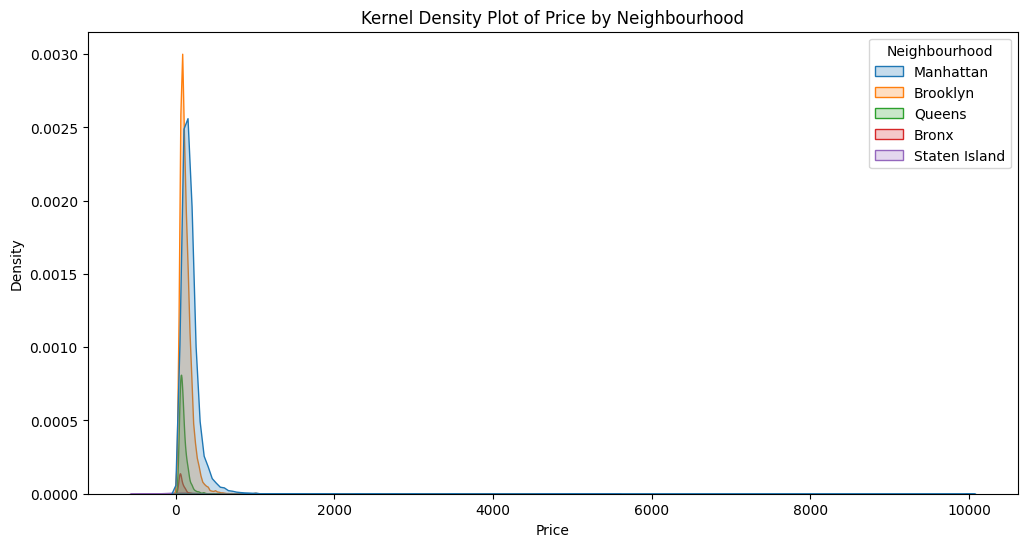

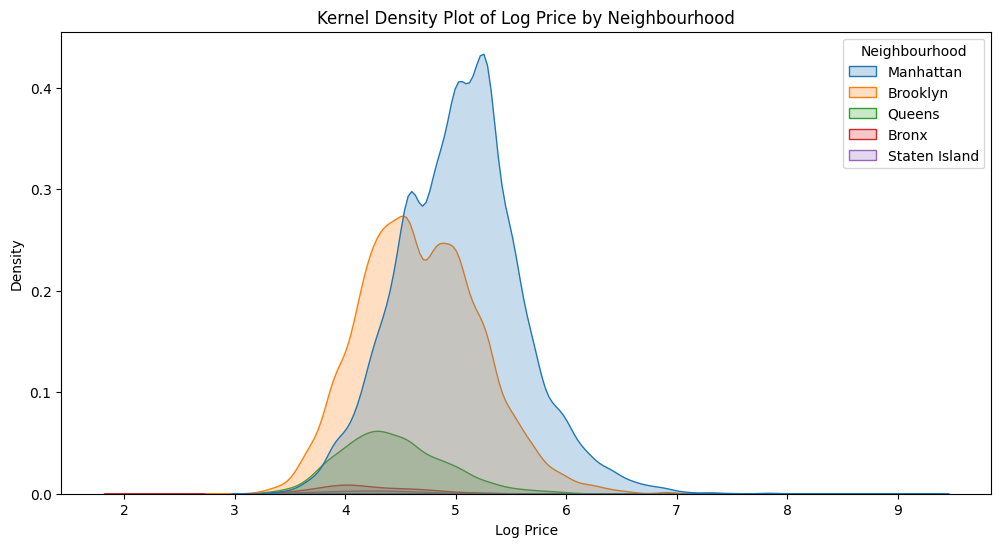


Regression Results (no intercept):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 29 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:23:18   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

,Regression Coefficient,Group Mean (from Q2.1)
Bronx,NaN,75.276498
Brooklyn,NaN,127.747378
Manhattan,NaN,183.664286
Bronx,75.276498,NaN
Brooklyn,127.747378,NaN
Manhattan,183.664286,NaN
Queens,96.857233,NaN
Staten Island,146.166667,NaN
Queens,NaN,96.857233
Staten Island,NaN,146.166667



Pattern observed: The regression coefficients for each neighbourhood (when no intercept is included and all dummy variables are present) are equal to the average price for that respective neighbourhood.

Interpretation: In a regression of a continuous variable on one categorical variable without an intercept, the coefficients represent the mean of the continuous variable for each category.

Regression Results for Q2 Part 2.3 (with intercept, Bronx as reference):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 29 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        21:23:18   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:              

In [11]:
# QUESTION 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

#2.1
clean_data = pd.read_csv("Q1_clean.csv")
clean_data = clean_data.rename(columns={'Neighbourhood ': 'Neighbourhood'})

neighbourhood_summary = clean_data.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values(by='Price', ascending=False)
display(neighbourhood_summary)

most_expensive_borough = neighbourhood_summary.index[0]
print(f"The most expensive borough on average is: {most_expensive_borough}")

plt.figure(figsize=(12, 6))
sns.kdeplot(data=clean_data, x='Price', hue='Neighbourhood', fill=True)
plt.title('Kernel Density Plot of Price by Neighbourhood')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(12, 6))
sns.kdeplot(data=clean_data, x=np.log(clean_data['Price']), hue='Neighbourhood', fill=True)
plt.title('Kernel Density Plot of Log Price by Neighbourhood')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.show()


#2.2
X_q2_2 = pd.get_dummies(clean_data['Neighbourhood'], prefix='Neighbourhood', drop_first=False).astype(int)
y_q2_2 = clean_data['Price']
model_q2_2 = sm.OLS(y_q2_2, X_q2_2)
results_q2_2 = model_q2_2.fit()

print("\nRegression Results (no intercept):")
print(results_q2_2.summary())

regression_coefficients = results_q2_2.params

print("\nComparison of Regression Coefficients (no intercept) and Group Means:")
comparison_df = pd.DataFrame({
    'Regression Coefficient': regression_coefficients,
    'Group Mean from Part 1': neighbourhood_summary['Price']
})
comparison_df.index = [col.replace('Neighbourhood_', '') for col in comparison_df.index]
display(comparison_df)
# The patterns that I observed that the regression coefficients for each neighborhood,
# when no intercept is included and all dummy variables are present, are equal to the
# average price for that respective neighborhood. In a regression of a continuous variable
# on one categorical variable without an intercept, the coefficients represent the mean
# of the continuous variable for each category.

#2.3
X_q2_3 = pd.get_dummies(clean_data['Neighbourhood'], prefix='Neighbourhood', drop_first=True).astype(int)
y_q2_3 = clean_data['Price']
X_q2_3 = sm.add_constant(X_q2_3)
model_q2_3 = sm.OLS(y_q2_3, X_q2_3)
results_q2_3 = model_q2_3.fit()

print("\nRegression Results (with intercept, Bronx as reference):")
print(results_q2_3.summary())

# The intercept represents the average price for the reference category, which is Bronx.
# The coefficients for the dummy variables represent the difference in average price
# between that neighborhood and the reference category (Bronx).

print("\nDeriving coefficients from Q2 Part 2 (no intercept) and Q2 Part 2.3 (with intercept):")
intercept = results_q2_3.params['const']
bronx_mean = intercept
print(f"Bronx mean (from Q2.3 intercept): {bronx_mean:.2f}")

for col, coeff in results_q2_3.params.drop('const').items():
    neighbourhood_name = col.replace('Neighbourhood_', '')
    mean_price = intercept + coeff
    print(f"{neighbourhood_name} mean: {mean_price:.2f} (Intercept + Coefficient for {neighbourhood_name})")

# The above shows that each coefficient from 2.2 can be obtained by adding the intercept
# from 2.3 to the corresponding dummy variable's coefficient from 2.3.


# 2.4

X_q2_4 = clean_data[['Review Scores Rating']].copy()
X_q2_4 = pd.concat([X_q2_4, pd.get_dummies(clean_data['Neighbourhood'], prefix='Neighbourhood', drop_first=True).astype(int)], axis=1)
y_q2_4 = clean_data['Price']
X_q2_4 = sm.add_constant(X_q2_4)

X_train_q2_4, X_test_q2_4, y_train_q2_4, y_test_q2_4 = train_test_split(X_q2_4, y_q2_4, test_size=0.2, random_state=42)

model_q2_4 = sm.OLS(y_train_q2_4, X_train_q2_4)
results_q2_4 = model_q2_4.fit()

print("\nRegression Results for 2.4:")
print(results_q2_4.summary())

y_pred_q2_4 = results_q2_4.predict(X_test_q2_4)

r2_q2_4 = r2_score(y_test_q2_4, y_pred_q2_4)
rmse_q2_4 = np.sqrt(mean_squared_error(y_test_q2_4, y_pred_q2_4))

print(f"\nR^2 on the test set (Q2 Part 2.4): ",r2_q2_4)
print(f"RMSE on the test set (Q2 Part 2.4): ",rmse_q2_4)

coeff_review_scores_q2_4 = results_q2_4.params['Review Scores Rating']
print(f"Coefficient on Review Scores Rating (Q2 Part 2.4): ", coeff_review_scores_q2_4)

neighbourhood_coeffs = results_q2_4.params.filter(regex='Neighbourhood_')
most_expensive_neighbourhood_relative = neighbourhood_coeffs.idxmax()
max_predicted_price_index = y_pred_q2_4.idxmax()
most_expensive_property_details = clean_data.loc[max_predicted_price_index]

print("\nMost expensive property details based on the model predictions (Q2 Part 2.4):\n")
print(f"Predicted Max Price: {y_pred_q2_4.max():.2f}")
print(f"Corresponding Actual Price: {most_expensive_property_details['Price']}")
print(f"Neighbourhood: {most_expensive_property_details['Neighbourhood']}")
print(f"Review Scores Rating: {most_expensive_property_details['Review Scores Rating']}")
# Based on the coefficients, Manhattan, which has the largest positive coefficient
# relative to the Bronx, combined with a high Review Scores Rating would generally
# represent the most expensive kind of property within this model.


# 2.5

X_q2_5 = clean_data[['Review Scores Rating']].copy()
X_q2_5 = pd.concat([
    X_q2_5,
    pd.get_dummies(clean_data['Neighbourhood'], prefix='Neighbourhood', drop_first=True).astype(int),
    pd.get_dummies(clean_data['Property Type'], prefix='Property_Type', drop_first=True).astype(int)
], axis=1)
y_q2_5 = clean_data['Price']

X_q2_5 = sm.add_constant(X_q2_5)

X_train_q2_5, X_test_q2_5, y_train_q2_5, y_test_q2_5 = train_test_split(X_q2_5, y_q2_5, test_size=0.2, random_state=42)

model_q2_5 = sm.OLS(y_train_q2_5, X_train_q2_5)
results_q2_5 = model_q2_5.fit()

print("\nRegression Results for 2.5:")
print(results_q2_5.summary())

y_pred_q2_5 = results_q2_5.predict(X_test_q2_5)

r2_q2_5 = r2_score(y_test_q2_5, y_pred_q2_5)
rmse_q2_5 = np.sqrt(mean_squared_error(y_test_q2_5, y_pred_q2_5))

print(f"\nR^2 on the test set (Q2 Part 2.5): {r2_q2_5:.4f}")
print(f"RMSE on the test set (Q2 Part 2.5): {rmse_q2_5:.2f}")

coeff_review_scores_q2_5 = results_q2_5.params['Review Scores Rating']
print(f"Coefficient on Review Scores Rating for 2.5: {coeff_review_scores_q2_5:.2f}")

neighbourhood_coeffs_2_5 = results_q2_5.params.filter(regex='Neighbourhood_')
property_type_coeffs_2_5 = results_q2_5.params.filter(regex='Property_Type_')

all_property_types = pd.get_dummies(clean_data['Property Type'], prefix='Property_Type', drop_first=False).columns.tolist()
included_property_types = property_type_coeffs_2_5.index.tolist()

all_property_type_names = [col.replace('Property_Type_', '') for col in all_property_types]
included_property_type_names = [col.replace('Property_Type_', '') for col in included_property_types]

reference_property_type = next(iter(set(all_property_type_names) - set(included_property_type_names)))

print(f"\nReference Neighbourhood: Bronx")
print(f"Reference Property Type: {reference_property_type}")

print("\nMost expensive kind of property (based on coefficients and high review score):")
# The highest predicted price will likely come from the combination of the intercept,
# the higher positive neighborhood coefficient (Manhattan), the highest positive property type coefficient,
# and a high Review Scores Rating (100)

max_predicted_price_index_q2_5 = y_pred_q2_5.idxmax()
most_expensive_property_details_q2_5 = clean_data.loc[max_predicted_price_index_q2_5]

print(f"Predicted Max Price: {y_pred_q2_5.max():.2f}")
print(f"Corresponding Actual Price: {most_expensive_property_details_q2_5['Price']}")
print(f"Neighbourhood: {most_expensive_property_details_q2_5['Neighbourhood']}")
print(f"Property Type: {most_expensive_property_details_q2_5['Property Type']}")
print(f"Review Scores Rating: {most_expensive_property_details_q2_5['Review Scores Rating']}")
# Generally, the most expensive kind of property will be the combination of the neighborhood
# with the highest positive coefficient (Manhattan) and the property type with the highest positive
# coefficient (a specific Property Type if its coefficient is highest and positive, otherwise the one that
# adds most to the base), along with a high review score. This model includes "Property Type" as an additional
# factor influencing price.

# 2.6

# If the Review Scores Rating changes from part 4 to part 5, it's because of the inclusion of
# Property Type in the model for part 5. This is known as the motted variable bias. In part 4,
# the model predicted Price based on Review Scores Rating and Neighborhood. If Property Type has
# an effect on Price and is also correlated with Review Scores Rating, then some of the effect that
# should be attributed to Property Type was inadvertently captured by the Review Scores Rating coefficient.
# When Property Type was added to the model in Part 5, the model is better able to isolate the unique
# contribution of Review Scores Rating to the Price, holding Property Type and Neighborhood constant.
# This leads to a more accurate and smaller estimate of the Review Scores Rating's independent effect,
# as some of the variance it previously explained is now explained by Property Type.


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 91.6+ KB

Initial DataFrame Head:


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000



Missing values before cleaning:


,0
Unnamed: 0,0
Make,0
Make_Year,0
Color,0
Body_Type,0
Mileage_Run,0
No_of_Owners,0
Seating_Capacity,0
Fuel_Type,0
Transmission,0



Missing values after dropping NA rows:


...

,Unnamed: 0,Make,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Car_Age,Price_log,Mileage_Run_log
0,1,Volkswagen,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9,13.395441,10.705758
1,2,Hyundai,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10,13.432786,9.918672
2,3,Honda,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7,13.583580,10.293534
3,4,Renault,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9,12.933624,10.482374
4,5,Hyundai,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9,13.151924,10.131698



Summary of Price:


,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06



Summary of Log-transformed Price (Price_log):


,Price_log
count,976.000000
mean,13.411035
std,0.450275
min,12.144203
25%,13.072649
50%,13.409797
75%,13.691082
max,14.894261


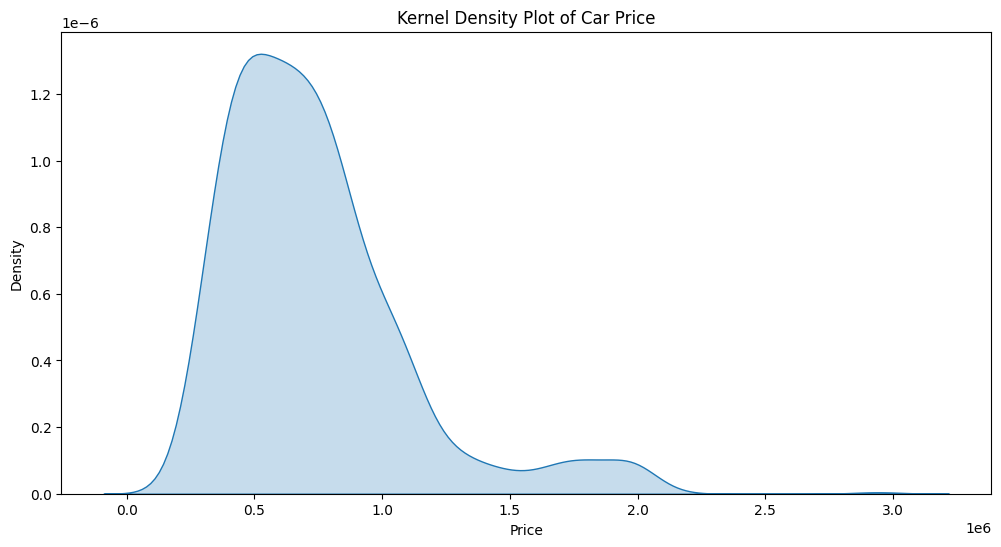

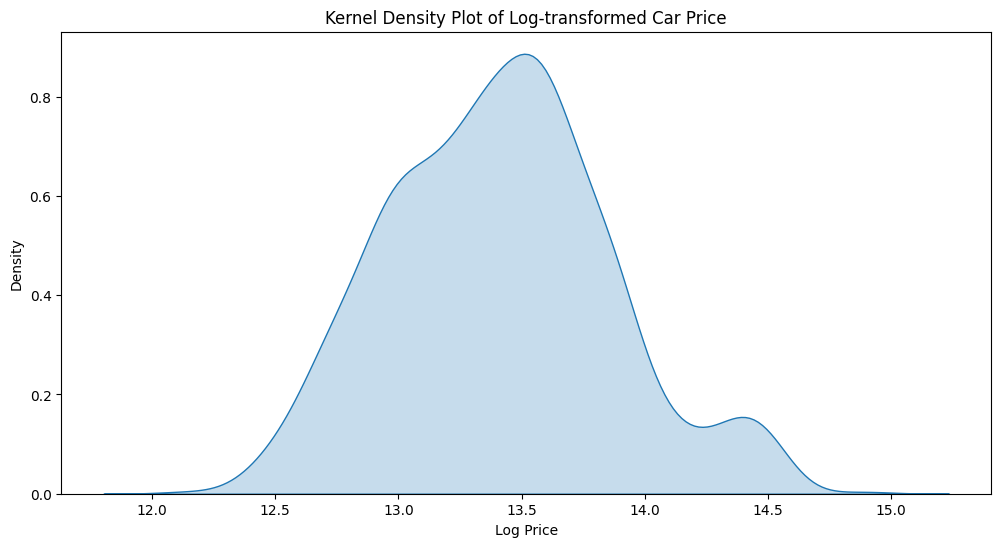


Price summary by Make:


,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
Skoda,5.0,1.136000e+06,1.070175e+06,436000.0,466000.0,538000.0,1299000.0,2941000.0
Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0
Tata,23.0,1.055217e+06,5.578305e+05,188000.0,779500.0,869000.0,1552000.0,2100000.0
Nissan,4.0,8.842500e+05,2.895599e+05,475000.0,782500.0,978000.0,1079750.0,1106000.0
Toyota,50.0,8.003400e+05,2.466900e+05,368000.0,526250.0,894000.0,1023000.0,1092000.0
Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0


/tmp/ipykernel_5382/382253593.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')


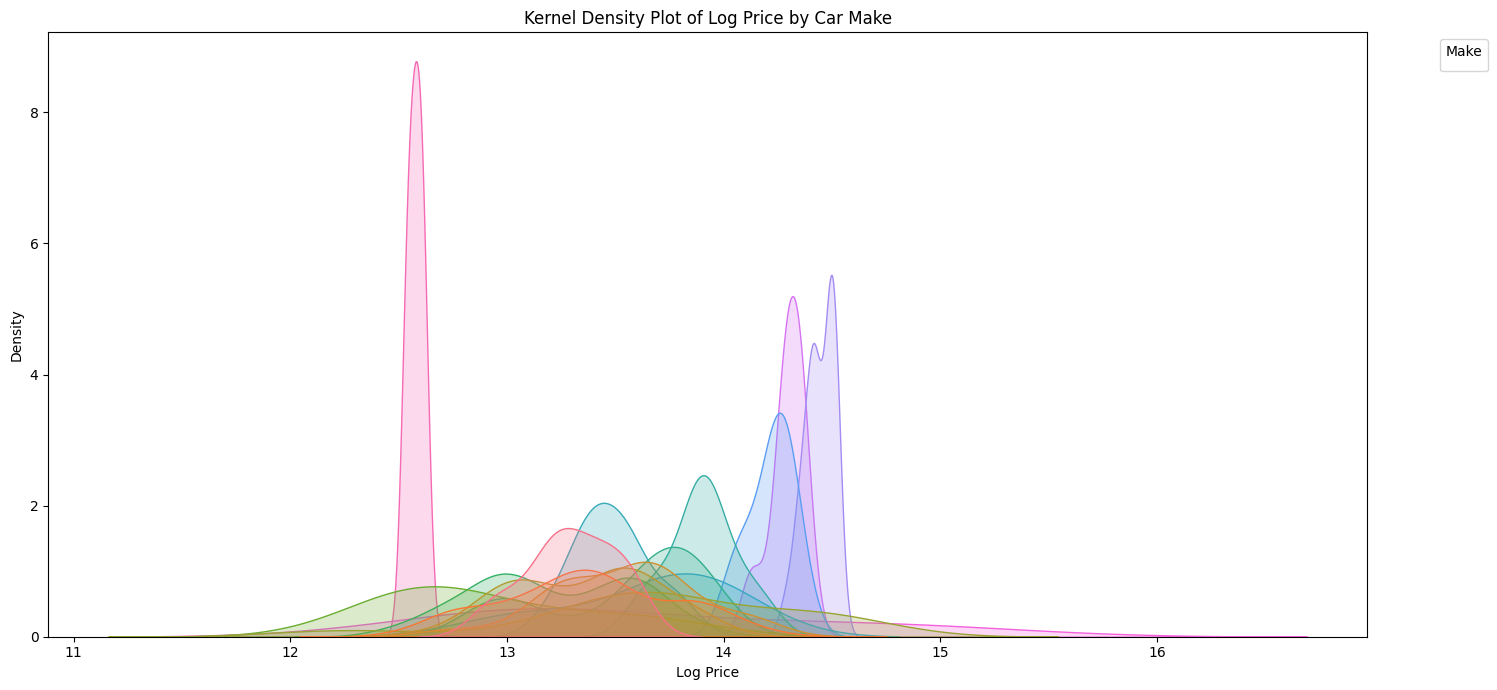

Data splitting complete.
Training set size: 780 samples
Test set size: 196 samples


,Mileage_Run_log,Seating_Capacity,Car_Age
679,9.798460,5,8
625,10.771491,5,13
33,9.502263,5,5
31,9.273503,5,13
883,10.497063,5,9


,Price_log
679,13.967374
625,13.028055
33,13.917165
31,13.191891
883,13.413541



Regression Results for Numeric Model (Q3.4 - Part 1):
                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     191.1
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           9.15e-93
Time:                        01:43:40   Log-Likelihood:                -273.36
No. Observations:                 780   AIC:                             554.7
Df Residuals:                     776   BIC:                             573.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

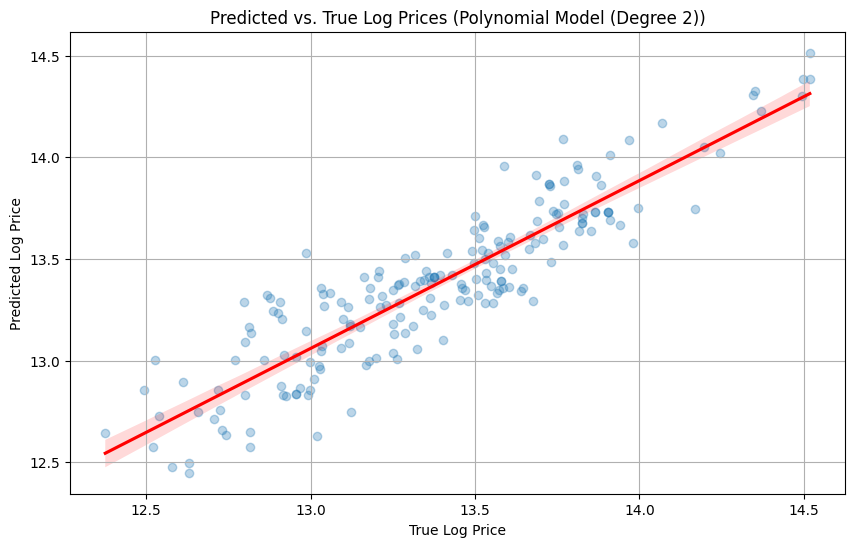

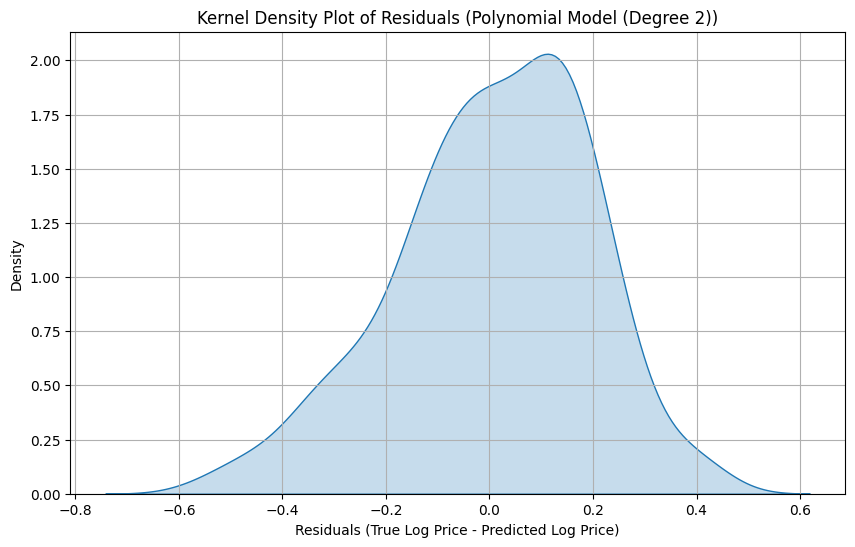

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 3.1
cars_df = pd.read_csv('cars_hw.csv')
print("Initial DataFrame Info:")
cars_df.info()
print("\nInitial DataFrame Head:")
display(cars_df.head())
print("\nMissing values before cleaning:")
display(cars_df.isnull().sum())
cars_df.dropna(inplace=True)
print("\nMissing values after dropping NA rows:")
display(cars_df.isnull().sum())
current_year = pd.Timestamp.now().year
cars_df['Car_Age'] = current_year - cars_df['Make_Year']
cars_df.drop('Make_Year', axis=1, inplace=True)
cars_df['Price_log'] = np.log1p(cars_df['Price'])
cars_df['Mileage_Run_log'] = np.log1p(cars_df['Mileage_Run'])
print("\nCleaned DataFrame Info:")
cars_df.info()
print("\nCleaned DataFrame Head (with new features):")
display(cars_df.head())


# 3.2
print("\nSummary of Price:")
display(cars_df['Price'].describe())
print("\nSummary of Log-transformed Price (Price_log):")
display(cars_df['Price_log'].describe())
plt.figure(figsize=(12, 6))
sns.kdeplot(data=cars_df, x='Price', fill=True)
plt.title('Kernel Density Plot of Car Price')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()
plt.figure(figsize=(12, 6))
sns.kdeplot(data=cars_df, x='Price_log', fill=True)
plt.title('Kernel Density Plot of Log-transformed Car Price')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.show()

print("\nPrice summary by Make:")
display(cars_df.groupby('Make')['Price'].describe().sort_values(by='mean', ascending=False))

plt.figure(figsize=(15, 7))
sns.kdeplot(data=cars_df, x='Price_log', hue='Make', fill=True, common_norm=False)
plt.title('Kernel Density Plot of Log Price by Car Make')
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3.3
y = cars_df['Price_log']

X_numeric = cars_df[['Mileage_Run_log', 'Seating_Capacity', 'Car_Age']].copy()

categorical_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
X_categorical = cars_df[categorical_cols]
X_categorical_dummies = pd.get_dummies(X_categorical, drop_first=True).astype(int)

X_full = pd.concat([X_numeric, X_categorical_dummies], axis=1)

X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

X_train_numeric = X_train_full[X_numeric.columns]
X_test_numeric = X_test_full[X_numeric.columns]

X_train_categorical = X_train_full[X_categorical_dummies.columns]
X_test_categorical = X_test_full[X_categorical_dummies.columns]

print("Data splitting complete.")
print(f"Training set size: {len(X_train_full)} samples")
print(f"Test set size: {len(X_test_full)} samples")

display(X_train_numeric.head())
display(y_train.head())

# 3.4
# Model 1: Numeric variables alone
X_train_numeric_const = sm.add_constant(X_train_numeric)
X_test_numeric_const = sm.add_constant(X_test_numeric)

model_numeric = sm.OLS(y_train, X_train_numeric_const)
results_numeric = model_numeric.fit()
print("\nRegression Results for Numeric Model (Q3.4 - Part 1):")
print(results_numeric.summary())

y_train_pred_numeric = results_numeric.predict(X_train_numeric_const)
y_test_pred_numeric = results_numeric.predict(X_test_numeric_const)

r2_train_numeric = r2_score(y_train, y_train_pred_numeric)
rmse_train_numeric = np.sqrt(mean_squared_error(y_train, y_train_pred_numeric))
print(f"\nR^2 on the training set (Numeric Model): {r2_train_numeric:.4f}")
print(f"RMSE on the training set (Numeric Model): {rmse_train_numeric:.4f}")

r2_test_numeric = r2_score(y_test, y_test_pred_numeric)
rmse_test_numeric = np.sqrt(mean_squared_error(y_test, y_test_pred_numeric))
print(f"R^2 on the test set (Numeric Model): {r2_test_numeric:.4f}")
print(f"RMSE on the test set (Numeric Model): {rmse_test_numeric:.4f}")


# Model 2: Categorical variables alone
X_train_categorical_const = sm.add_constant(X_train_categorical)
X_test_categorical_const = sm.add_constant(X_test_categorical)

model_categorical = sm.OLS(y_train, X_train_categorical_const)
results_categorical = model_categorical.fit()
print("\nRegression Results for Categorical Model (Q3.4 - Part 2):")
print(results_categorical.summary())

y_train_pred_categorical = results_categorical.predict(X_train_categorical_const)
y_test_pred_categorical = results_categorical.predict(X_test_categorical_const)

r2_train_categorical = r2_score(y_train, y_train_pred_categorical)
rmse_train_categorical = np.sqrt(mean_squared_error(y_train, y_train_pred_categorical))
print(f"\nR^2 on the training set (Categorical Model): {r2_train_categorical:.4f}")
print(f"RMSE on the training set (Categorical Model): {rmse_train_categorical:.4f}")

r2_test_categorical = r2_score(y_test, y_test_pred_categorical)
rmse_test_categorical = np.sqrt(mean_squared_error(y_test, y_test_pred_categorical))
print(f"R^2 on the test set (Categorical Model): {r2_test_categorical:.4f}")
print(f"RMSE on the test set (Categorical Model): {rmse_test_categorical:.4f}")

# Compare Numeric vs Categorical Model
print("\nComparison of Numeric and Categorical Models:")
print(f"Numeric Model Test R^2: {r2_test_numeric:.4f}")
print(f"Categorical Model Test R^2: {r2_test_categorical:.4f}")
print(f"Numeric Model Test RMSE: {rmse_test_numeric:.4f}")
print(f"Categorical Model Test RMSE: {rmse_test_categorical:.4f}")

if r2_test_categorical > r2_test_numeric:
    print("The Categorical-only model performs better on the test set (higher R^2).")
    best_model_3_4_r2 = r2_test_categorical
    best_model_3_4_rmse = rmse_test_categorical
    best_model_3_4_name = "Categorical Model"
else:
    print("The Numeric-only model performs better on the test set (higher R^2).")
    best_model_3_4_r2 = r2_test_numeric
    best_model_3_4_rmse = rmse_test_numeric
    best_model_3_4_name = "Numeric Model"

# Model 3: Combined Numeric and Categorical variables
X_train_combined_const = sm.add_constant(X_train_full)
X_test_combined_const = sm.add_constant(X_test_full)

model_combined = sm.OLS(y_train, X_train_combined_const)
results_combined = model_combined.fit()
print("\nRegression Results for Combined Model (Q3.4 - Part 3):")
print(results_combined.summary())

y_train_pred_combined = results_combined.predict(X_train_combined_const)
y_test_pred_combined = results_combined.predict(X_test_combined_const)

r2_train_combined = r2_score(y_train, y_train_pred_combined)
rmse_train_combined = np.sqrt(mean_squared_error(y_train, y_train_pred_combined))
print(f"\nR^2 on the training set (Combined Model): {r2_train_combined:.4f}")
print(f"RMSE on the training set (Combined Model): {rmse_train_combined:.4f}")

r2_test_combined = r2_score(y_test, y_test_pred_combined)
rmse_test_combined = np.sqrt(mean_squared_error(y_test, y_test_pred_combined))
print(f"R^2 on the test set (Combined Model): {r2_test_combined:.4f}")
print(f"RMSE on the test set (Combined Model): {rmse_test_combined:.4f}")

# Compare Combined Model with previous best
print("\nComparison of Combined Model with previous best:")
print(f"Previous Best Model ({best_model_3_4_name}) Test R^2: {best_model_3_4_r2:.4f}")
print(f"Combined Model Test R^2: {r2_test_combined:.4f}")
print(f"Previous Best Model ({best_model_3_4_name}) Test RMSE: {best_model_3_4_rmse:.4f}")
print(f"Combined Model Test RMSE: {rmse_test_combined:.4f}")

if r2_test_combined > best_model_3_4_r2:
    print(f"The Combined Model performs better than the {best_model_3_4_name} by {r2_test_combined - best_model_3_4_r2:.4f} R^2 points.")
    best_model_so_far_r2 = r2_test_combined
    best_model_so_far_rmse = rmse_test_combined
    best_model_so_far_name = "Combined Model"
else:
    print(f"The {best_model_3_4_name} still performs better or equally.")
    best_model_so_far_r2 = best_model_3_4_r2
    best_model_so_far_rmse = best_model_3_4_rmse
    best_model_so_far_name = best_model_3_4_name

# 3.5
from sklearn.preprocessing import PolynomialFeatures

X_numeric_for_poly = cars_df[['Mileage_Run_log', 'Seating_Capacity', 'Car_Age']]

poly_results = []
max_degree = 4
for degree in range(1, max_degree + 1):
    print(f"\nTesting Polynomial Features with degree = {degree}")
    poly = PolynomialFeatures(degree=degree, include_bias=False) # include_bias=False as sm.add_constant will add it later
    X_poly = poly.fit_transform(X_numeric_for_poly)
    X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X_numeric_for_poly.columns))

    X_full_poly = pd.concat([X_poly_df, X_categorical_dummies], axis=1)

    X_train_poly_full, X_test_poly_full, y_train_poly, y_test_poly = train_test_split(X_full_poly, y, test_size=0.2, random_state=42)

    X_train_poly_const = sm.add_constant(X_train_poly_full)
    X_test_poly_const = sm.add_constant(X_test_poly_full)

    model_poly = sm.OLS(y_train_poly, X_train_poly_const)
    results_poly = model_poly.fit()

    y_pred_poly = results_poly.predict(X_test_poly_const)
    r2_test_poly = r2_score(y_test_poly, y_pred_poly)
    rmse_test_poly = np.sqrt(mean_squared_error(y_test_poly, y_pred_poly))

    print(f"  R^2 on the test set: {r2_test_poly:.4f}")
    print(f"  RMSE on the test set: {rmse_test_poly:.4f}")

    poly_results.append({
        'degree': degree,
        'r2_test': r2_test_poly,
        'rmse_test': rmse_test_poly,
        'model_results': results_poly,
        'X_test_const': X_test_poly_const,
        'y_test': y_test_poly,
        'y_pred': y_pred_poly
    })

    if r2_test_poly < 0:
        print(f"  R^2 went negative at degree {degree}.")

best_poly_model = max(poly_results, key=lambda x: x['r2_test'])
print(f"\nBest Polynomial Model: Degree {best_poly_model['degree']}")
print(f"  R^2 on the test set: {best_poly_model['r2_test']:.4f}")
print(f"  RMSE on the test set: {best_poly_model['rmse_test']:.4f}")

print("\nComparison of Best Polynomial Model with Best Model from Q3.4:")
print(f"Best Model from Q3.4 ({best_model_so_far_name}) Test R^2: {best_model_so_far_r2:.4f}")
print(f"Best Model from Q3.4 ({best_model_so_far_name}) Test RMSE: {best_model_so_far_rmse:.4f}")
print(f"Best Polynomial Model (Degree {best_poly_model['degree']}) Test R^2: {best_poly_model['r2_test']:.4f}")
print(f"Best Polynomial Model (Degree {best_poly_model['degree']}) Test RMSE: {best_poly_model['rmse_test']:.4f}")

if best_poly_model['r2_test'] > best_model_so_far_r2:
    print(f"The Best Polynomial Model performs better than the {best_model_so_far_name}.")
    best_model_final_r2 = best_poly_model['r2_test']
    best_model_final_rmse = best_poly_model['rmse_test']
    best_model_final_name = f"Polynomial Model (Degree {best_poly_model['degree']})"
    final_y_pred = best_poly_model['y_pred']
    final_y_test = best_poly_model['y_test']
else:
    print(f"The {best_model_so_far_name} still performs better or equally.")
    best_model_final_r2 = best_model_so_far_r2
    best_model_final_rmse = best_model_so_far_rmse
    best_model_final_name = best_model_so_far_name
    if best_model_so_far_name == "Combined Model":
        final_y_pred = y_test_pred_combined
        final_y_test = y_test
    elif best_model_so_far_name == "Categorical Model":
        final_y_pred = y_test_pred_categorical
        final_y_test = y_test
    else:
        final_y_pred = y_test_pred_numeric
        final_y_test = y_test


# 3.6
print(f"Evaluating the best model: {best_model_final_name}")
print(f"Test R^2: {best_model_final_r2:.4f}")
print(f"Test RMSE: {best_model_final_rmse:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x=final_y_test, y=final_y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('True Log Price')
plt.ylabel('Predicted Log Price')
plt.title(f'Predicted vs. True Log Prices ({best_model_final_name})')
plt.grid(True)
plt.show()

residuals = final_y_test - final_y_pred

plt.figure(figsize=(10, 6))
sns.kdeplot(residuals, fill=True)
plt.title(f'Kernel Density Plot of Residuals ({best_model_final_name})')
plt.xlabel('Residuals (True Log Price - Predicted Log Price)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Some strengths of the model are that the r^2 value indicates that a significant portion
# of the variance in car prices is explained by the model's features.
# The predicted vs true values plot shows a generally positive correlation, suggesting
# the model captures the overall trend.
# The kernel density plot of residuals is somewhat bell-shaped and centered around
# zero, which is desirable for OLS assumptions, indicating no obvious bias.
# Some weaknesses are that the spread of points around the red line in the predicted
# vs. true values plot, especially at higher prices, suggests some heteroscedasticity
# or remaining uncaptured variance.
# The residuals plot, while somewhat bell-shaped, might show some deviation from a
# perfect normal distribution, particularly in the tails, indicating potential outliers
# or non-linearities no fully accounted for.
# Log transformations of price helps, but prediction accuracy might still be lower for
# extremely high-priced cars.
# The model's performance could potentially be improved by incorporating more features,
# interaction terms, or more advanced modeling techniques if non-linear relationships
# are prominent.


**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

I uploaded my answers to question 4 to the GitHub as a PDF!
